In [14]:
from datetime import datetime
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.linalg import expm

import scipy.sparse as sp

In [15]:
def spectral_expansion(v,N):
    # N is number of points I want to map to
    ## vv is the coefficients associated with wavelengths from a lower spatial resolution
    vlen = int(len(v)/2)
    v_expanded = np.zeros(N, dtype=complex)
    v_expanded[:(vlen)] = v[:(vlen)]
    v_expanded[-(vlen):] = v[-(vlen):]
    return v_expanded

In [29]:


def ks_equation(N, h = 1/16):
    print(h)
    time_start = time.time()
    x = 32 * np.pi * np.arange(1, N+1) / N
    u = np.cos(x/16) * (1 + np.sin(x/16))
    v = np.fft.fft(u)

    # Precompute various ETDRK4 scalar quantities
    h = 1/4  # time step
    k = np.concatenate([ np.arange(0, N//2), [0], np.arange(-N//2+1, 0)]) / 16  # wave numbers
    L = k**2 - k**4  # Fourier multipliers
    E = np.exp(h * L)
    E2 = np.exp(h * L / 2)
    M = 16  # number of points for complex means
    r = np.exp(1j * np.pi * (np.arange(1, M+1) - 0.5) / M)  # roots of unity

    LR = h * L[:, None] + r[None, :]
    Q = h * np.real(np.mean((np.exp(LR / 2) - 1) / LR, axis=1))
    f1 = h * np.real(np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3, axis=1))
    f2 = h * np.real(np.mean((2 + LR + np.exp(LR) * (-2 + LR)) / LR**3, axis=1))
    f3 = h * np.real(np.mean((-4 - 3 * LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3, axis=1))

    # Main time-stepping loop
    uu = u
    vv = v


    tt = [0]
    tmax = 150
    nmax = round(tmax / h)
    nplt = int(np.floor((tmax / 100) / h))
    g = -0.5j * k





    for n in range(1, nmax+1):
        t = n * h
        Nv = g * np.fft.fft(np.real(np.fft.ifft(v))**2)
        a = E2 * v + Q * Nv
        Na = g * np.fft.fft(np.real(np.fft.ifft(a))**2)
        b = E2 * v + Q * Na
        Nb = g * np.fft.fft(np.real(np.fft.ifft(b))**2)
        c = E2 * a + Q * (2 * Nb - Nv)
        Nc = g * np.fft.fft(np.real(np.fft.ifft(c))**2)
        
        v = E * v + Nv * f1 + 2 * (Na + Nb) * f2 + Nc * f3
        
        if n % nplt == 0:
            u = np.real(np.fft.ifft(v))
            uu = np.vstack([uu, u])

            vv = np.vstack([vv, v])
            tt.append(t)
    
    time_end = time.time()
    elapsed_time = time_end - time_start
    print(f"KS equation simulation completed in {elapsed_time:.2f} seconds.")
    
    
    return [x, tt, uu, vv, elapsed_time]

In [ ]:
def ETDFDM_KS(N,h = 1/4):
    time_start = time.time()

    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(0,N)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)
    print("Linear operator constructed. Computing ETD-RK4 coefficients...")

    I = np.eye(N)
    ##Linear operator L:
    L = -(D2+D4)

    ##ETD quantities

    M = 64

    r = 15 * np.exp(1j *2* np.pi * (np.arange(1, M+1) - 0.5) / M)

    A = h * L
    E = expm(A)
    E2 = expm(A / 2)

    I = np.eye(N)
    Z = np.zeros((N, N))

    f1 = Z.copy()
    f2 = Z.copy()
    f3 = Z.copy()
    Q  = Z.copy()
    print("Computing ETD-RK4 coefficients...")
    for j in range(M):
        z = r[j]
        zIA = np.linalg.inv(z * I - A)
        
        Q  = Q + h * zIA * (np.exp(z/2) - 1)
        f1 = f1 + h * zIA * (-4 - z + np.exp(z)*(4 - 3*z + z**2)) / z**2
        f2 = f2 + h * zIA * (2 + z + np.exp(z)*(z - 2)) / z**2
        f3 = f3 + h * zIA * (-4 - 3*z - z**2 + np.exp(z)*(4 - z)) / z**2

    Q  = np.real(Q)/M
    f1 = np.real(f1)/M
    f2 = np.real(f2)/M
    f3 = np.real(f3)/M
    if np.any(np.isnan(Q)) or np.any(np.isnan(f1)) or np.any(np.isnan(f2)) or np.any(np.isnan(f3)):
        print(f"NaN encountered at in setup; stopping time-stepping.")
        return [x, [0], u.reshape(-1, 1), 0]
    if np.any(np.isinf(Q)) or np.any(np.isinf(f1)) or np.any(np.isinf(f2)) or np.any(np.isinf(f3)):
        print(f"Inf encountered at in setup; stopping time-stepping.")
        return [x, [0], u.reshape(-1, 1), 0]



    print("ETD-RK4 coefficients computed. Starting time-stepping...")
    print("E eigenvalues:", np.max(np.abs(np.linalg.eigvalsh(E))))
    print("Q max value:", np.max(np.abs(Q)))
    print("E2 max value:", np.max(np.abs(E2)))
    print("Any NaNs in Q?", np.any(np.isnan(Q)))
    

    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    tmax = 150
    nmax = round(tmax / h)
    nplt = int(np.floor((tmax / 100) / h))

    for n in range(1, nmax + 1):
        #print("n = ", n)
        t = n * h

        Nu = -u*(D1@u)
        a  = E2 @ u + Q @ Nu
        Na = -a*(D1@a)

        b  = E2 @ u + Q @ Na
        Nb = -b*(D1@b)
        
        c  = E2 @ a + Q @ (2*Nb - Nu)
        Nc = -c*(D1@c)
        if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.any(np.isnan(c)):
            print(f"NaN encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break
        if np.any(np.isinf(a)) or np.any(np.isinf(b)) or np.any(np.isinf(c)):
            print(f"Inf encountered at step {n}, t={t:.6g}; stopping time-stepping.")
            break


        u = E @ u + f1 @ Nu + 2*f2 @ (Na + Nb) + f3 @ Nc

        if n % nplt == 0:
            #print("Saving at t = ", t)
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)
            if n%(10*nplt) == 0:
                print("you have completed", n/nmax)
            
    time_end = time.time()
    time_elapsed = time_end - time_start
    print(f"ETD_KS execution time: {time_elapsed} seconds")

    return [x, tt, uu, time_elapsed]

In [ ]:
def Finite_KS(N,mu):

    ##ut = -u*ux - uxx - uxxxx
    ##u_n+1 = u_n + h*(-u_n*ux_n - uxx_n - uxxxx_n)
    ##u_n+1 = u_n + h*(-u_n*D1@u_n - D2@u_n - D4@u_n)
    ##Forward Euler scheme for KS equation with periodic BCs
    ##FDM quantities
    ##Discretise space:
    x = 32*np.pi*np.arange(1,N+1)/N
    dx = x[1] - x[0]
    ##set initial conditions
    u = np.cos(x/16) * (1 + np.sin(x/16))
    ## Differentiation matrices plus identity:
    D1 = sp.diags([-1,0,1],[-1,0,1],shape=(N,N)).toarray()

    D2 = sp.diags([1,-2,1],[-1,0,1],shape=(N,N)).toarray()

    D4 = sp.diags([1,-4,6,-4,1],[-2,-1,0,1,2], shape=(N,N)).toarray()

    D1[0,-1] = -1
    D1[-1,0] = D2[0,-1] = D2[-1,0] = D4[0,-2] = D4[1,-1] = D4[-2,0] = D4[-1,1]= 1
    D4[-1,0] = D4[0,-1] = -4

    D1 = D1/(2*dx)
    D2 = D2/(dx**2)
    D4 = D4/(dx**4)

    h = (dx**4) * mu
    tmax = 150
    nmax = round(tmax / h)
    nplt = int(np.floor((tmax / 100) / h))
    print(nplt)
    uu = u.reshape(-1, 1)
    tt = np.array([0.0])

    for i in range(1, nmax + 1):
        t = i * h
        u = u + h*(-u*(D1@u) - D2@u - D4@u)

        if i % nplt == 0:
            uu = np.hstack((uu, u.reshape(-1, 1)))
            tt = np.append(tt, t)  
            if i%(nplt*10) == 0:
                print(i/(nmax), "done")

    return [x, tt, uu]


In [55]:
N = 2**10
x,tt,uu,vv,elapsed_time = ks_equation(N, h =1/16)

0.0625
KS equation simulation completed in 0.18 seconds.


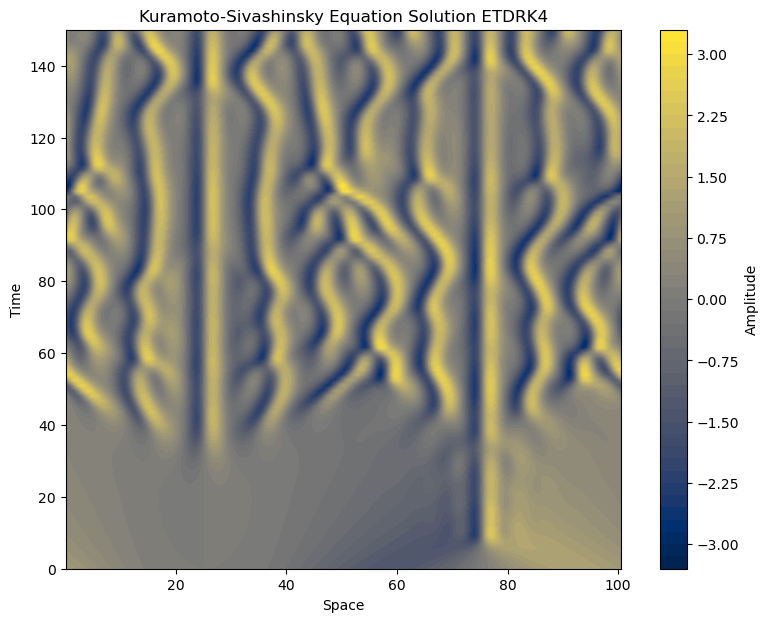

In [56]:
# Plot results using a contour plot
fig, ax = plt.subplots(figsize=(10, 7))
X, T = np.meshgrid(x, tt)
contour = ax.contourf(X, T, uu[:,::-1], levels=50, cmap=cm.cividis)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('Amplitude')
#adjust aspect ratio
ax.set_aspect(0.65)
# Set labels and title
ax.set_xlabel('Space')
ax.set_ylabel('Time')
ax.set_title('Kuramoto-Sivashinsky Equation Solution ETDRK4')

plt.show()